# DAY2 — 첫 모델 비교: 선형 회귀와 Ridge

목적은 설계한 대안을 동일한 CV에서 비교하고, 특징·모델을 유지하거나 교체할 이유를 확인하는 것이다. 개발 집합 29개만 사용하며 Hold-out·Batch 2 성능은 아직 산출하지 않는다.

중앙값 기준 1개 + 선형 회귀 4개 + Ridge 16개 = 21개 구성, 각 5-fold 검증. F1은 log10 ΔQ 분산, F2는 여기에 마스킹 초기 QD 기울기를 추가한다. 타깃은 변환하지 않은 수명 또는 log10 수명이다.

**Feature는 입력 정보, Target은 예측할 정답이다.** F1·F2는 모델 이름이 아니라 입력 조합의 이름이다. ΔQ 분산 입력은 log10 변환을 사용하지만, Target은 전체 수명 cycle_life를 변환하지 않고 학습할 수도 있다. 로그 Target과 입력의 로그 변환은 별개다. 여기서 전체 수명은 100회 이후 남은 수명을 뜻하지 않는다.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/day2_linear_comparison.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.day2_linear_comparison import configurations, make_model, evaluate, save_figures
from src.day2_dataset import F1, F2
print('커널:', sys.executable)
train = pd.read_parquet(ROOT / 'data/processed/day2/train_batch1.parquet')
development = train.loc[train.partition.eq('development')].sort_values(['batch','cell_id']).reset_index(drop=True)
assert len(development) == 29
print('이번 비교에 사용하는 개발 항목:', len(development))

커널: /Users/soobin/myfolder/workspace/mini-project-data-analysis/.venv/bin/python
이번 비교에 사용하는 개발 항목: 29


## 1. 설계가 코드로 구현되는 방식

선형 회귀와 Ridge는 `StandardScaler → 회귀 모델` Pipeline이다. 각 fold의 학습 행만으로 scaler를 적합한다. 로그 변환한 Target은 TransformedTargetRegressor로 변환하고 예측 시 10의 거듭제곱으로 복원한다. 중앙값 모델도 fold 학습 수명만 사용한다.

Ridge는 alpha 0.1·1·10·100을 비교한다. 높은 alpha의 점수를 높이는 것이 목표가 아니라 계수·예측 변화를 확인하는 실험이다.

In [2]:
configs = list(configurations())
display(pd.DataFrame(configs))
display(make_model(next(x for x in configs if x['config_id'] == 'ridge_F2_log10_a1')))

,config_id,model,feature_set,target,alpha
0,median_raw,median,F1,raw,NaN
1,ols_F1_raw,ols,F1,raw,NaN
2,ridge_F1_raw_a0.1,ridge,F1,raw,0.1
3,ridge_F1_raw_a1,ridge,F1,raw,1.0
4,ridge_F1_raw_a10,ridge,F1,raw,10.0
5,ridge_F1_raw_a100,ridge,F1,raw,100.0
6,ols_F1_log10,ols,F1,log10,NaN
7,ridge_F1_log10_a0.1,ridge,F1,log10,0.1
8,ridge_F1_log10_a1,ridge,F1,log10,1.0
9,ridge_F1_log10_a10,ridge,F1,log10,10.0


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.","Pipeline(step...n', Ridge())])"
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log10'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<function inv...t 0x10e73a3e0>
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common

## 2. 고정 CV로 학습·검증

같은 config마다 개발 셀 한 개당 학습에서 제외됐을 때의 예측(OOF)이 하나씩 생긴다. 모든 후보에 동일한 5-fold를 사용한다. 평균 MAPE는 fold별 MAPE의 단순 평균이며, pooled OOF MAPE와 구분한다.

In [3]:
summary, fold_scores, oof_predictions, coefficients, scaler_statistics = evaluate(development)
assert len(fold_scores) == 105 and len(oof_predictions) == 21 * 29
assert not oof_predictions.duplicated(['config_id','barcode_key']).any()
display(summary)
TABLES = ROOT / 'outputs/tables/day2/linear_comparison'
if (TABLES / 'summary.csv').exists():
    saved = pd.read_csv(TABLES / 'summary.csv')
    np.testing.assert_allclose(summary.mean_fold_mape_pct, saved.mean_fold_mape_pct, rtol=1e-12)
    print('저장된 결과와 재실행 결과가 일치한다.')

,config_id,model,feature_set,target,alpha,mean_fold_mape_pct,std_fold_mape_pct,worst_fold_mape_pct,mean_fold_mae_cycles,mean_fold_rmse_cycles,pooled_oof_mape_pct,oof_n,nonpositive_prediction_n
0,ridge_F1_raw_a0.1,ridge,F1,raw,0.1,8.612355,2.001813,10.985726,69.840220,88.027896,8.650342,29,0
1,ols_F1_raw,ols,F1,raw,NaN,8.616772,1.991773,10.996753,69.889489,88.078260,8.656105,29,0
2,ridge_F1_raw_a1,ridge,F1,raw,1.0,8.631433,2.022685,10.890618,69.757450,87.701869,8.659764,29,0
3,ridge_F1_log10_a1,ridge,F1,log10,1.0,8.864134,1.792042,10.434291,71.529409,90.434579,8.834735,29,0
4,ridge_F1_log10_a0.1,ridge,F1,log10,0.1,8.872679,1.725825,10.450673,71.786229,90.880061,8.847853,29,0
5,ols_F1_log10,ols,F1,log10,NaN,8.873789,1.719124,10.467476,71.816724,90.942934,8.849483,29,0
6,ridge_F1_log10_a10,ridge,F1,log10,10.0,9.451564,1.922892,11.675472,74.325200,92.595920,9.405603,29,0
7,ridge_F1_raw_a10,ridge,F1,raw,10.0,9.564892,1.815608,11.689290,74.556602,91.247793,9.536514,29,0
8,ridge_F2_log10_a10,ridge,F2,log10,10.0,9.972797,2.012872,12.423522,78.212943,95.394337,9.961191,29,0
9,ridge_F2_raw_a10,ridge,F2,raw,10.0,9.975645,2.036165,12.313670,77.655634,93.542505,9.979811,29,0


저장된 결과와 재실행 결과가 일치한다.


## 3. 특징과 규제 비교

In [4]:
selected_ids = ['median_raw','ols_F1_raw','ridge_F1_raw_a0.1','ols_F2_raw','ridge_F2_raw_a10']
display(summary.loc[summary.config_id.isin(selected_ids)])
display(fold_scores.loc[fold_scores.config_id.isin(selected_ids)].pivot(index='fold', columns='config_id', values='mape_pct'))

,config_id,model,feature_set,target,alpha,mean_fold_mape_pct,std_fold_mape_pct,worst_fold_mape_pct,mean_fold_mae_cycles,mean_fold_rmse_cycles,pooled_oof_mape_pct,oof_n,nonpositive_prediction_n
0,ridge_F1_raw_a0.1,ridge,F1,raw,0.1,8.612355,2.001813,10.985726,69.840220,88.027896,8.650342,29,0
1,ols_F1_raw,ols,F1,raw,NaN,8.616772,1.991773,10.996753,69.889489,88.078260,8.656105,29,0
9,ridge_F2_raw_a10,ridge,F2,raw,10.0,9.975645,2.036165,12.313670,77.655634,93.542505,9.979811,29,0
15,ols_F2_raw,ols,F2,raw,NaN,11.331986,4.390400,18.619839,85.403630,102.750517,11.080681,29,0
20,median_raw,median,F1,raw,NaN,16.416236,4.523413,24.199423,123.540000,145.169722,16.147851,29,0


config_id,median_raw,ols_F1_raw,ols_F2_raw,ridge_F1_raw_a0.1,ridge_F2_raw_a10
fold,,,,,
1,15.362873,6.493499,8.158102,6.449655,8.556237
2,12.422430,10.996753,11.376840,10.985726,11.670781
3,14.566498,7.643788,7.629890,7.624592,7.482713
4,15.529958,10.473711,10.875262,10.491077,12.313670
5,24.199423,7.476106,18.619839,7.510724,9.854825


F1 선형 회귀는 중앙값 기준보다 모든 fold에서 좋았다. F2 선형 회귀는 5개 중 4개 fold에서 F1보다 나빴고, 특히 fold 5의 오차가 커졌다. Ridge는 F2의 큰 편차를 줄였지만 F1보다 좋은 구성은 되지 않았다. F1 선형 회귀와 Ridge alpha 0.1은 거의 같았다.

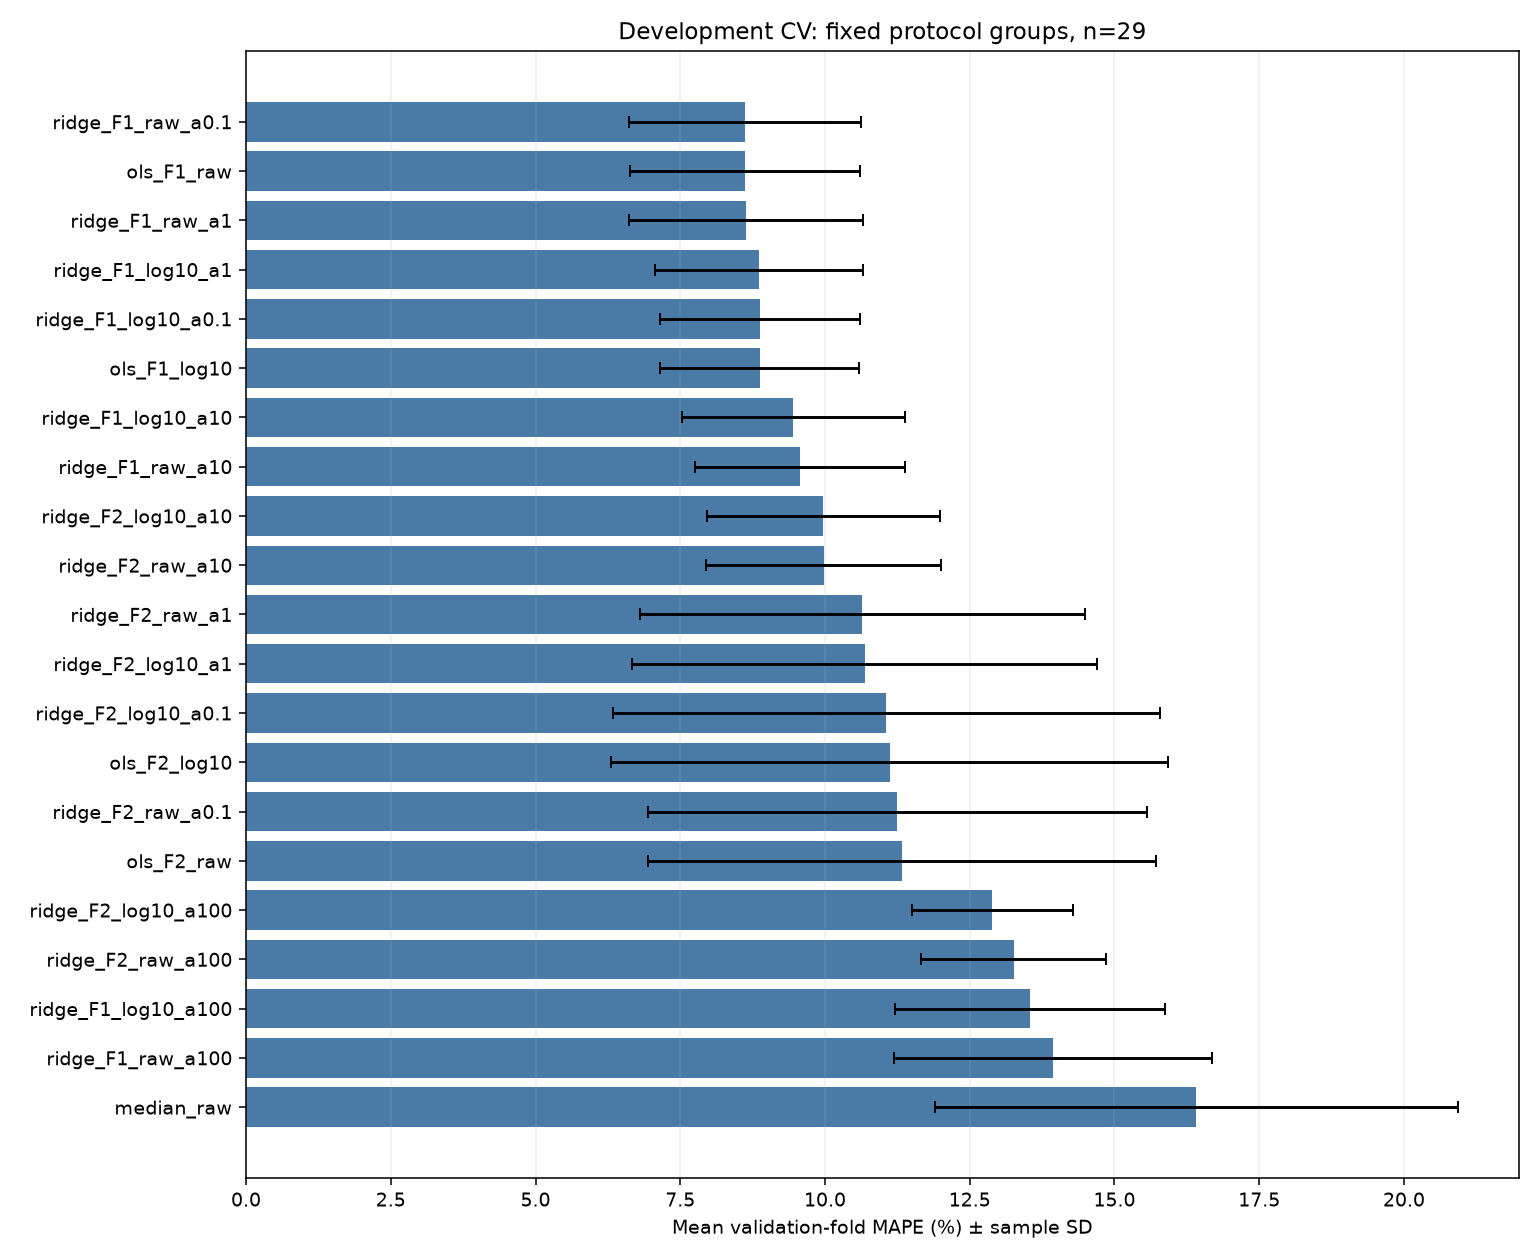

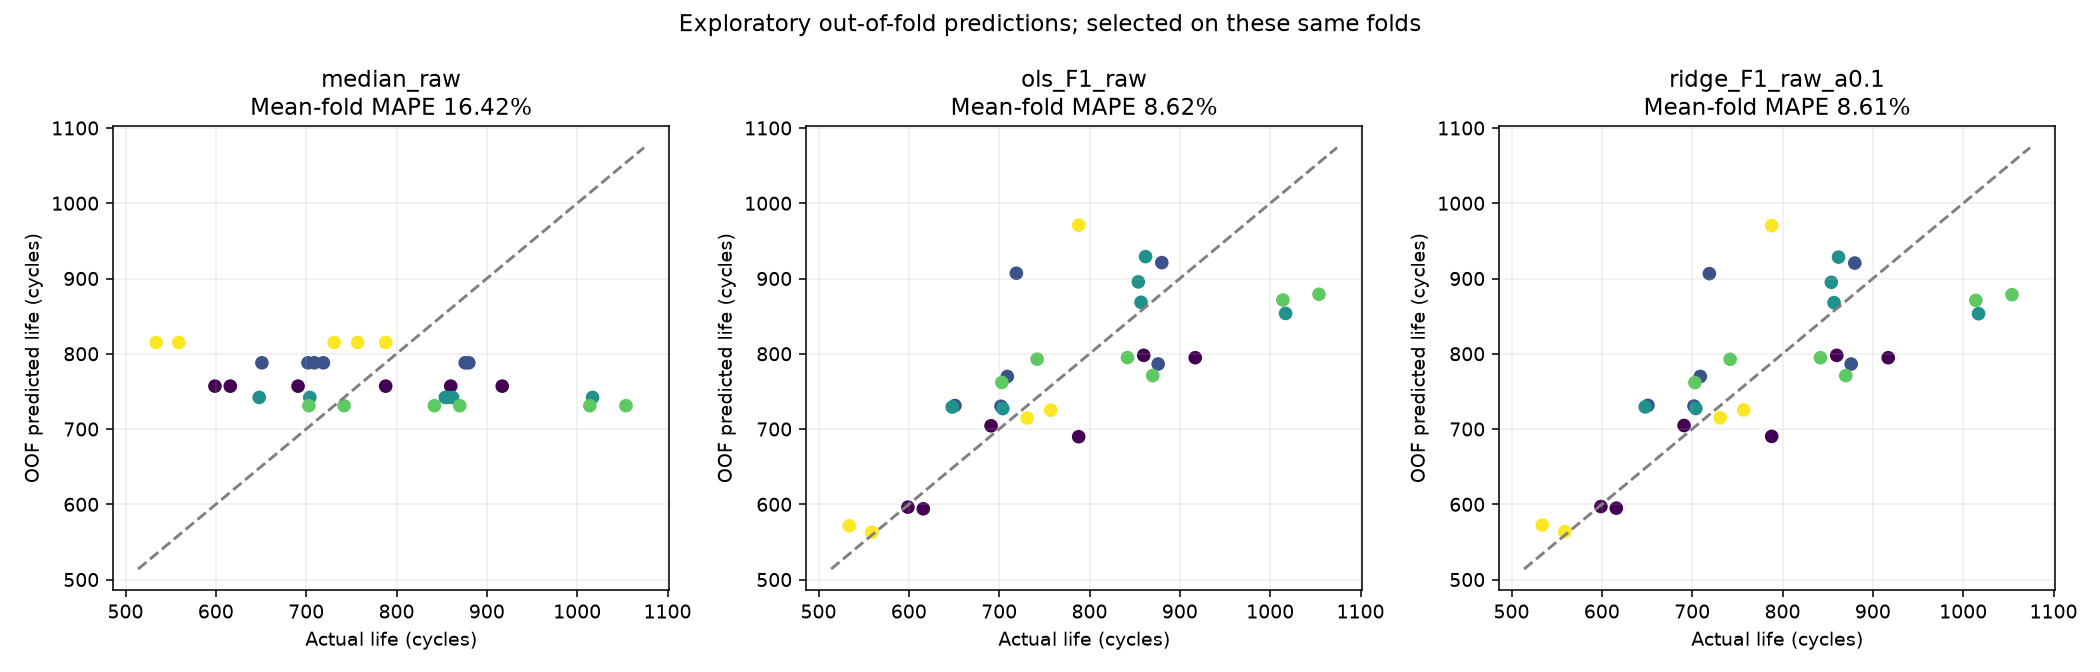

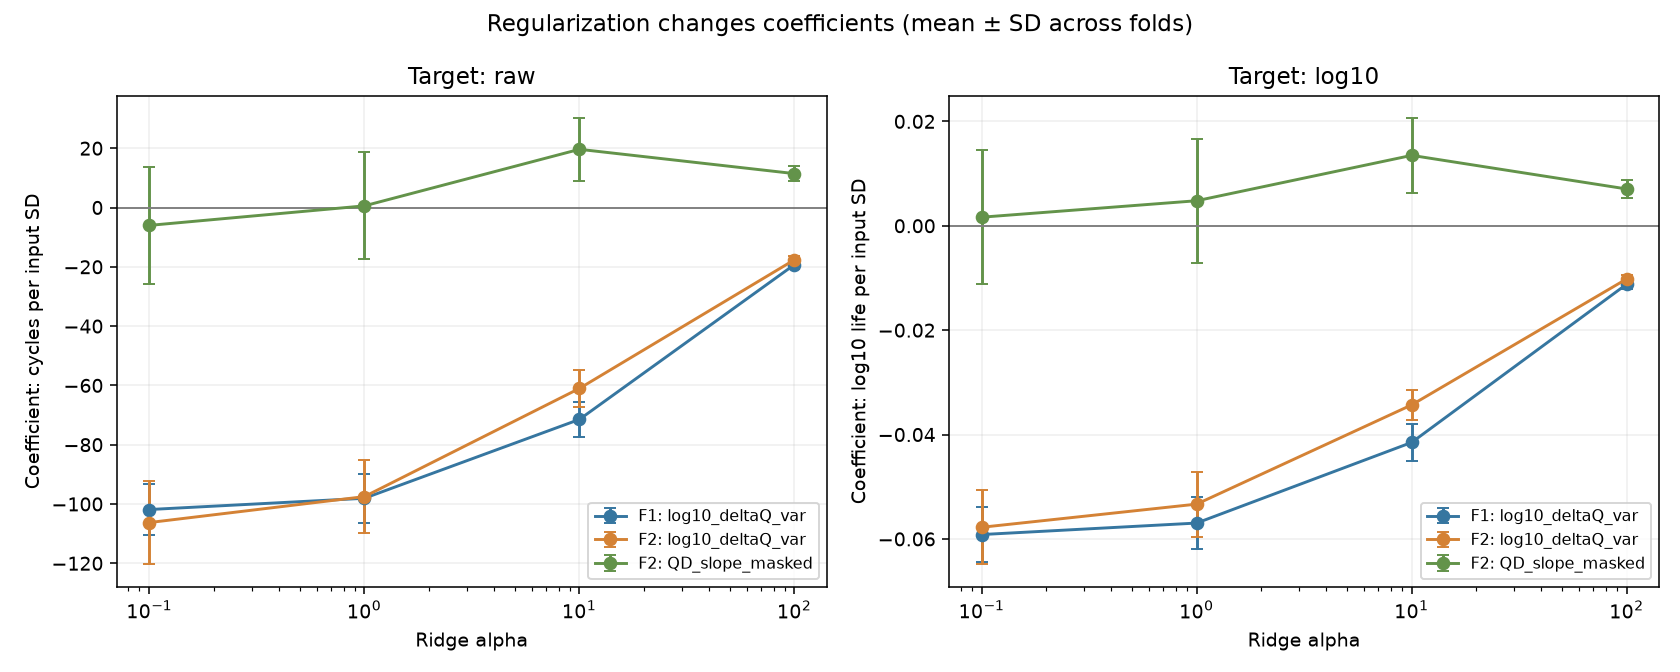

In [5]:
save_figures(summary, fold_scores, oof_predictions, coefficients)
FIGURES = ROOT / 'outputs/figures/day2/linear_comparison'
for name in ['01_cv_comparison.png','02_oof_predictions.png','03_ridge_coefficients.png']:
    display(Image(filename=str(FIGURES / name)))

## 4. 계수와 학습 fold의 표준화 값

표준화 입력 계수는 해당 fold 학습 입력 표준편차 한 단위의 변화와 연결된다. 변환하지 않은 수명 계수와 로그 수명 계수는 단위가 달라 직접 크기를 비교하지 않는다. 기울기 계수의 부호 변화는 이 자료에서 보조 효과가 불안정한 단서이며 인과 효과를 뜻하지 않는다.

In [6]:
display(coefficients.loc[coefficients.config_id.isin(['ols_F1_raw','ols_F2_raw'])])
first_scaler = scaler_statistics.loc[scaler_statistics.config_id.eq('ols_F1_raw') & scaler_statistics.fold.eq(1)]
training_fold1 = development.loc[development.cv_valid_fold.ne(1)]
np.testing.assert_allclose(first_scaler.train_mean, training_fold1[F1].mean().to_numpy())
display(first_scaler)
print('fold 1 학습 데이터만 사용한 평균:', training_fold1[F1].mean().to_dict())

,config_id,model,feature_set,target,alpha,fold,feature,coefficient_scaled_input,coefficient_original_input,intercept_scaled_input,intercept_original_input
0,ols_F1_raw,ols,F1,raw,NaN,1,log10_deltaQ_var,-102.421276,-4.808736e+02,785.782609,-1050.903104
1,ols_F1_raw,ols,F1,raw,NaN,2,log10_deltaQ_var,-115.989188,-5.019797e+02,782.913043,-1109.918174
2,ols_F1_raw,ols,F1,raw,NaN,3,log10_deltaQ_var,-103.511214,-4.698513e+02,765.304348,-996.993133
3,ols_F1_raw,ols,F1,raw,NaN,4,log10_deltaQ_var,-93.727984,-4.088744e+02,753.000000,-780.752257
4,ols_F1_raw,ols,F1,raw,NaN,5,log10_deltaQ_var,-95.905430,-5.124272e+02,798.958333,-1154.007472
50,ols_F2_raw,ols,F2,raw,NaN,1,log10_deltaQ_var,-116.565823,-5.472831e+02,785.782609,-1314.418614
51,ols_F2_raw,ols,F2,raw,NaN,1,QD_slope_masked,-17.363580,-4.916344e+05,785.782609,-1314.418614
52,ols_F2_raw,ols,F2,raw,NaN,2,log10_deltaQ_var,-109.791371,-4.751567e+02,782.913043,-1002.772090
53,ols_F2_raw,ols,F2,raw,NaN,2,QD_slope_masked,8.315230,2.415606e+05,782.913043,-1002.772090
54,ols_F2_raw,ols,F2,raw,NaN,3,log10_deltaQ_var,-104.043670,-4.722682e+02,765.304348,-1006.593433


,config_id,model,feature_set,target,alpha,fold,feature,train_mean,train_scale
0,ols_F1_raw,ols,F1,raw,NaN,1,log10_deltaQ_var,-3.819477,0.21299


fold 1 학습 데이터만 사용한 평균: {'log10_deltaQ_var': -3.819476779404867}


## 5. 평균 점수 밖의 셀별 오차

In [7]:
display(oof_predictions.loc[oof_predictions.config_id.eq('ols_F1_raw')].nlargest(5,'ape_pct')[['cell_id','protocol_key','fold','actual_life','predicted_life','ape_pct']])

,cell_id,protocol_key,fold,actual_life,predicted_life,ape_pct
36,15,5.4C(60%)-3C,2,719.0,907.010625,26.148905
53,11,5.4C(50%)-3C,5,788.0,970.975263,23.220211
47,9,5.4C(40%)-3.6C,4,1054.0,879.025907,16.600958
43,24,6C(40%)-3C,3,1017.0,853.592760,16.067575
48,23,6C(30%)-3.6C,4,1014.0,871.424917,14.060659


## 6. 이번 결정과 다음 대안

- 다음 단계의 주 후보: **F1 + 변환하지 않은 수명 + 일반 선형 회귀**. Ridge와 거의 같은 결과를 더 적은 설정으로 얻었다.
- 비교 후보: **F1 + 변환하지 않은 수명 + Ridge(alpha=0.1)**. 평균 MAPE 수치상 1위지만 약 0.004%p 차이를 확정적 우위로 보지 않는다.
- F2는 기본 입력에서 제외하고 보조 대안으로 남긴다. 변환하지 않은 수명을 우선하되 로그 변환한 Target의 작은 차이만으로 일반적 우열을 확정하지 않는다.
- 다음 실험은 ΔQ 최솟값 대체와 QD 유지/마스킹 비교다. F1은 QD 기울기를 사용하지 않으므로 QD 마스킹 변경은 F1의 입력을 바꾸지 않는다. 이후 제한된 부스팅과 비교한다.

보고한 CV로 후보를 선택했으므로 이 점수는 독립 최종 성능이 아니다. Hold-out·Batch 2·목표 9.1%와의 Gap은 이후 단계에서 평가한다.

[비교·선택 근거 보고서](../outputs/reports/day2/linear_comparison_report.md) · [실험 코드](../src/day2_linear_comparison.py)